In [9]:
import os
import re
import tempfile
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib-cache"))

warnings.filterwarnings("ignore", category=RuntimeWarning, module="statsmodels")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="numpy")
warnings.filterwarnings("ignore", message="IProgress not found.*")
try:
    from tqdm import TqdmWarning
    warnings.filterwarnings("ignore", category=TqdmWarning)
except Exception:
    pass

import graphviz
import numpy as np
import pandas as pd
import statsmodels.api as sm
from dowhy import CausalModel
from IPython.display import display
from sklearn.preprocessing import RobustScaler

In [10]:
TOOL_NAME = 'CodeQL'
INPUT_FILE = 'alerts_with_lib_category_and_apk_size_codeql.csv'
COMMON_CAUSES = ['apk_size_scaled', 'app_popularity_encoded']
METHOD_NAME = 'backdoor.generalized_linear_model'
CATEGORY_ORDER = ['<100', '100-500', '500-1k', '1k-5k', '5k-10k', '10k-50k', '50k-100k', '100k-500k', '500k-1M', '1M-5M', '>5M']
GRAPH_7 = '\ndigraph {\n    combined -> verdict;\n    apk_size_scaled -> combined;\n    apk_size_scaled -> verdict;\n    app_popularity_encoded -> combined;\n    app_popularity_encoded -> verdict;\n}\n'

In [11]:
def normalize_verdict(value):
    normalized = str(value).strip().lower()
    if normalized in {"1", "true"}:
        return 1
    if normalized in {"0", "false"}:
        return 0
    raise ValueError(f"Unsupported verdict value: {value!r}")


def normalize_rule_id(value):
    if pd.isna(value):
        return "missing"
    value = str(value).strip()
    if not value:
        return "missing"
    return re.sub(r"[^0-9A-Za-z_]+", "_", value)


def print_refutation(method, ref):
    print(f"\nRefuter: {method}")
    if isinstance(ref, list):
        for item in ref:
            print(item)
    else:
        print(ref)


def get_refutation_value(ref, attribute):
    if isinstance(ref, list):
        return [getattr(item, attribute, None) for item in ref]
    return getattr(ref, attribute, None)

## Load and Prepare Data

The `combined` treatment is constructed exactly as in the binary-treatment notebook: all classified alerts are assigned `combined = 1`, then developer-written alerts are duplicated as the control group with `combined = 0`.

In [12]:
df = pd.read_csv(INPUT_FILE)
print("Original rows:", len(df))

df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()
print("After removing obfuscated:", len(df))

df["verdict"] = df["verdict"].apply(normalize_verdict)
df["is_3rd_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)
df["is_third_party"] = df["is_3rd_party"]

rule_id_source_column = "rule_id" if "rule_id" in df.columns else "ruleId"
if rule_id_source_column in df.columns:
    df["rule_id"] = df[rule_id_source_column].apply(normalize_rule_id)

df_all = df.copy()
df_all["combined"] = 1
df_developer_written = df[df["code_location"] == "developer_written"].copy()
df_developer_written["combined"] = 0
df = pd.concat([df_all, df_developer_written], ignore_index=True)

popularity_column = "app_popularity" if "app_popularity" in df.columns else "apk_category"
df["app_popularity_encoded"] = pd.Categorical(
    df[popularity_column],
    categories=CATEGORY_ORDER,
    ordered=True,
).codes

df = df[df["app_popularity_encoded"] >= 0].copy()
df = df.dropna(subset=["apk_size", "combined", "verdict", "app_popularity_encoded"]).copy()

scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])
df = df.drop(columns=["propensity_score"], errors="ignore").copy()

print("Popularity column:", popularity_column)
print("Combined counts:")
print(df["combined"].value_counts().sort_index())
print("Verdict counts:")
print(df["verdict"].value_counts().sort_index())

Original rows: 21501
After removing obfuscated: 21501
Popularity column: apk_category
Combined counts:
combined
0      554
1    21501
Name: count, dtype: int64
Verdict counts:
verdict
0     2421
1    19634
Name: count, dtype: int64


## Graph 7

This is the selected final causal graph from the binary-treatment analysis.

Tool: CodeQL
Estimator: backdoor.generalized_linear_model
Common causes: ['apk_size_scaled', 'app_popularity_encoded']


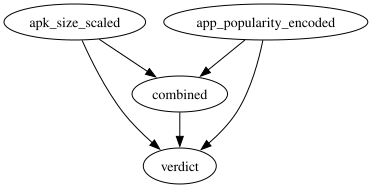

In [13]:
print("Tool:", TOOL_NAME)
print("Estimator:", METHOD_NAME)
print("Common causes:", COMMON_CAUSES)
display(graphviz.Source(GRAPH_7))

## Logistic Regression Adjustment with DoWhy

This uses DoWhy's `backdoor.generalized_linear_model` estimator with the `statsmodels` Binomial family. The ATE is estimated on the predicted probability scale for `verdict = 1`.

In [14]:
model = CausalModel(
    data=df,
    treatment="combined",
    outcome="verdict",
    graph=GRAPH_7.replace("\n", " "),
    common_causes=COMMON_CAUSES,
)

identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print("------- Identified estimand -------")
print(identified_estimand)

estimate = model.estimate_effect(
    identified_estimand,
    method_name=METHOD_NAME,
    target_units="ate",
    confidence_intervals="bootstrap",
    test_significance=True,
    method_params={
        "glm_family": sm.families.Binomial(),
        "predict_score": True,
        "num_simulations": 300,
        "sample_size_fraction": 1.0,
        "confidence_level": 0.95,
    },
)

print("\n------- Logistic-regression adjustment estimate -------")
print(estimate)
print("Mean value:", float(estimate.value))

try:
    ci = np.asarray(estimate.get_confidence_intervals()).reshape(-1)
    if len(ci) >= 2:
        print("95% confidence interval:", (float(ci[0]), float(ci[-1])))
except Exception as exc:
    print("95% confidence interval unavailable:", exc)

------- Identified estimand -------
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                        
───────────(E[verdict|app_popularity_encoded,apk_size_scaled])
d[combined]                                                   
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|combined,app_popularity_encoded,apk_size_scaled,U) = P(verdict|combined,app_popularity_encoded,apk_size_scaled)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                                        
───────────(E[verdict|app_popularity_encoded,apk_size_scaled])
d[combined]                                                   
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict th

## Refutation Tests

These are the same four refuters used in the main binary-treatment causal analysis.

In [15]:
refutation_methods = [
    "random_common_cause",
    "placebo_treatment_refuter",
    "data_subset_refuter",
    "dummy_outcome_refuter",
]

refutation_rows = []

for method in refutation_methods:
    try:
        if method == "placebo_treatment_refuter":
            ref = model.refute_estimate(
                identified_estimand,
                estimate,
                method_name=method,
                placebo_type="permute",
                num_simulations=200,
            )
        elif method == "data_subset_refuter":
            ref = model.refute_estimate(
                identified_estimand,
                estimate,
                method_name=method,
                subset_fraction=0.8,
                num_simulations=200,
            )
        elif method == "dummy_outcome_refuter":
            ref = model.refute_estimate(
                identified_estimand,
                estimate,
                method_name=method,
                num_simulations=200,
            )
        else:
            ref = model.refute_estimate(identified_estimand, estimate, method_name=method)

        print_refutation(method, ref)
        refutation_rows.append({
            "tool": TOOL_NAME,
            "graph": "Graph 7",
            "estimator": METHOD_NAME,
            "refuter": method,
            "estimated_effect": get_refutation_value(ref, "estimated_effect"),
            "new_effect": get_refutation_value(ref, "new_effect"),
            "p_value": get_refutation_value(ref, "p_value"),
            "error": None,
        })
    except Exception as exc:
        print(f"\nRefuter: {method}")
        print(f"Skipped because DoWhy could not run it for this estimand: {type(exc).__name__}: {exc}")
        refutation_rows.append({
            "tool": TOOL_NAME,
            "graph": "Graph 7",
            "estimator": METHOD_NAME,
            "refuter": method,
            "estimated_effect": None,
            "new_effect": None,
            "p_value": None,
            "error": f"{type(exc).__name__}: {exc}",
        })

refutation_df = pd.DataFrame(refutation_rows)
refutation_df


Refuter: random_common_cause
Refute: Add a random common cause
Estimated effect:-0.06405214513965818
New effect:-0.06404715807313313
p value:0.94


Refuter: placebo_treatment_refuter
Refute: Use a Placebo Treatment
Estimated effect:-0.06405214513965818
New effect:-0.00013731572831976013
p value:1.0


Refuter: data_subset_refuter
Refute: Use a subset of data
Estimated effect:-0.06405214513965818
New effect:-0.06402968932850163
p value:0.99


Refuter: dummy_outcome_refuter
Refute: Use a Dummy Outcome
Estimated effect:0
New effect:-0.004331972413966847
p value:0.87



,tool,graph,estimator,refuter,estimated_effect,new_effect,p_value,error
0,CodeQL,Graph 7,backdoor.generalized_linear_model,random_common_cause,-0.064052,-0.064047,None,None
1,CodeQL,Graph 7,backdoor.generalized_linear_model,placebo_treatment_refuter,-0.064052,-0.000137,None,None
2,CodeQL,Graph 7,backdoor.generalized_linear_model,data_subset_refuter,-0.064052,-0.06403,None,None
3,CodeQL,Graph 7,backdoor.generalized_linear_model,dummy_outcome_refuter,[0],[-0.004331972413966847],[None],None


## Summary

In [16]:
logistic_regression_adjustment_result = pd.DataFrame([
    {
        "tool": TOOL_NAME,
        "graph": "Graph 7",
        "estimator": METHOD_NAME,
        "common_causes": ", ".join(COMMON_CAUSES),
        "ATE": float(estimate.value),
    }
])
logistic_regression_adjustment_result

,tool,graph,estimator,common_causes,ATE
0,CodeQL,Graph 7,backdoor.generalized_linear_model,"apk_size_scaled, app_popularity_encoded",-0.064052
